## Fitting Translations $t^r_{r'}$, $t^m_c$

The relationship between the $c^r$ and $c^c$ can be derived by considering last column of the transformation of $\mathcal{H}^c$ to $\mathcal{H}^r$. 
\begin{align*}
    \begin{bmatrix}c^r\\1\end{bmatrix} &= T^r_{r'} T^{r'}_m T^m_{c} \begin{bmatrix}c^c\\1\end{bmatrix}\\
    c^r &= R^r_{r'} R^{r'}_m R^m_c c^c + R^r_{r'}R^{r'}_m t^m_c + R^r_{r'}t_m^{r'}+t^r_{r'}
\end{align*}
But since $c^c = \begin{bmatrix}0&0&0\end{bmatrix}^T$, so the above reduces to 
\begin{align*} c^r &=  R^r_{r'}R^{r'}_m t^m_c + R^r_{r'}t_m^{r'}+t^r_{r'}
\end{align*}
For each left and right camera model the translation from the mast frame $m$ to the camera frame $c$ as a linear function of $focus$
\begin{align*}
    t^m_{c,left}(focus) &= t^m_{c,left,0} + t^m_{c,left,1} * focus\\
    t^m_{c,right}(focus) &= t^m_{c,right,0} + t^m_{c,right,1} * focus
\end{align*}


Thus, in total we will need to solve for $t^r_{r'}$, $t^m_{c,left,0}$, $t^m_{c,left,1}$, $t^m_{c,right,0}$ and $t^m_{c,right,1}$ such that squared euclidean distance between the $c$ vector in the rover's reference frame is minimize, 
\begin{align*}
    \min_{t^r_{r'}, t^m_{c,left,0}, t^m_{c,left,1}, t^m_{c,right,0}, t^m_{c,right,1}} \sum_{i}\| c_i^r - (R^r_{r'}R^{r'}_{m,i} t^m_{c,i} + R^r_{r'}t_{m,i}^{r'}+t^r_{r'}) \|^2
\end{align*}


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

In [16]:
outliers = []

# focal length outliers
fl_outlier_fpath = "./focal_length_outliers.txt"
with open(fl_outlier_fpath,'r') as f:
  outliers += [l.strip() for l in f.readlines()]

# geocal outliers
gc_outlier_fpath = "./geocal_outliers.txt"
with open(gc_outlier_fpath,'r') as f:
  outliers += [l.strip() for l in f.readlines()]

data_fpath = "data/m41_site_cal_v229_v1_Z034_filtered.xlsx"
data = pd.read_excel(data_fpath)
print(f"Num data points: {len(data)}")

# Remove outliers
data = data[~data['name'].isin(outliers)]
print(f"Num data points after removing outliers: {len(data)}")

# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
data["c_r_vec" ] = [to_vec_space(v) for v in data["c_r_est"]]
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]
data["t_rpm_vec" ] = [to_vec_comma(v) for v in data["t_rpm"]]

zl34 = data[data["cam"] == "ZL034"].copy()
zl34.reset_index(drop=True, inplace=True)
zr34 = data[data["cam"] == "ZR034"].copy()
zr34.reset_index(drop=True, inplace=True)

data34 = pd.concat([zl34,zr34], axis=0).reset_index(drop=True)

print(f"Number of data points zl034 (all fmc):{zl34.shape[0]}")
print(f"Number of data points zr034 (all fmc):{zr34.shape[0]}")

Num data points: 640
Num data points after removing outliers: 508
Number of data points zl034 (all fmc):257
Number of data points zr034 (all fmc):251


In [36]:
q_rrp = [ 7.45645440e-05, 3.51676710e-04, -8.44843512e-04, -9.99999579e-01]
q_cm_zl_0 = [0.49057316, 0.50453528, 0.50674909, 0.49798343]
q_cm_zl_1 = [ 4.02486085e-05, -1.33691695e-04, -1.41653222e-04, 9.99999980e-01] 
q_cm_zr_0 = [0.50380067, 0.48965644, 0.49892107, 0.50744381] 
q_cm_zr_1 = [ 2.33921698e-05, -1.38814667e-05, -1.44154281e-04, 9.99999989e-01]

def get_c_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  c_i = np.expand_dims(data_["c_r_vec"][idx], axis=1)
  return c_i

def get_R_rrp()->np.ndarray:
  """
  Rotation matrix going from r to r_prime frame
  """
  return R.from_quat(q_rrp).as_matrix()

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_R_mc(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from mast frame to camera frame
  """
  f = data_["fmc"][idx]
  
  q_cm_0 = q_cm_zl_0 if data_["cam"][idx] == "ZL034" else q_cm_zr_0
  q_cm_1 = q_cm_zl_1 if data_["cam"][idx] == "ZR034" else q_cm_zr_1

  rot_mc_0 = R.from_quat(q_cm_0)
  rot_mc_1 = R.from_quat(q_cm_1)

  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  return rot_mc.as_matrix()

def get_t_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Translation vector going from r_prime to mast frame
  """
  return np.expand_dims(data_["t_rpm_vec"][idx], axis=1)

In [37]:
idx = 10

c_r = get_c_r_data(idx, zl34)
R_rrp = get_R_rrp()
R_rpm = get_R_rpm(idx, zl34)
R_mc = get_R_mc(idx, zl34)

print(f"c_r:\n{c_r}")
print(f"R_rrp:\n{R_rrp}")
print(f"R_rpm:\n{R_rpm}")
print(f"R_mc:\n{R_mc}")

c_r:
[[ 0.9127356 ]
 [ 0.4624217 ]
 [-1.91934804]]
R_rrp:
[[ 9.99998325e-01 -1.68963387e-03 -7.03479114e-04]
 [ 1.68973876e-03  9.99998561e-01  1.48534801e-04]
 [ 7.03227132e-04 -1.49723249e-04  9.99999742e-01]]
R_rpm:
[[ 0.38701128 -0.31619411 -0.86616601]
 [ 0.13134818  0.94869135 -0.28763238]
 [ 0.91267186 -0.00245235  0.40868577]]
R_mc:
[[-0.02269675 -0.00967682  0.99969556]
 [ 0.99972811  0.0051266   0.02274711]
 [-0.00534516  0.99994004  0.00955783]]


In [38]:
def dist_metric(c_r_data, c_r_model):
  return np.linalg.norm(c_r_data - c_r_model, ord=2)**2

def obj(x):
  obj_val = 0
  count = 0
  t_rrp = np.expand_dims(x[:3], axis=1)
  R_rrp = get_R_rrp()
  t_mc_zl_0 = np.expand_dims(x[3:6], axis=1)
  t_mc_zl_1 = np.expand_dims(x[6:9], axis=1)
  t_mc_zr_0 = np.expand_dims(x[9:12], axis=1)
  t_mc_zr_1 = np.expand_dims(x[12:], axis=1)

  for i in range(data34.shape[0]):  
    # compute the data
    c_r_data = get_c_r_data(i, data34)

    # compute the model
    f = data34["fmc"][i]
    R_rpm = get_R_rpm(i, data34)
    t_mc = t_mc_zl_0 + f * t_mc_zl_1 if data34["cam"][i]=="ZL034" else t_mc_zr_0 + f * t_mc_zr_1
    t_rpm = get_t_rpm(i, data34)
    
    

    c_r_model = R_rrp @ R_rpm @ t_mc + R_rrp @ t_rpm + t_rrp
    # c_r_model = np.expand_dims(c_r_model, axis=1)

    obj_val += dist_metric(c_r_data, c_r_model)
    count += 1
  
  return obj_val / count

# def jac(x):
#   jac_val = np.zeros(9)
#   count = 0
#   R_rrp = get_R_rrp()
#   for i in range(data34.shape[0]):  
#     # compute the data
#     c_r_data = get_c_r_data(i, data34)
    
#     # compute the model
#     f = data34["fmc"][i]
#     R_rpm = get_R_rpm(i, data34)
#     t_rrp = np.expand_dims(x[:3], axis=1)
#     t_rpm = get_t_rpm(i, data34)
#     t_mc = np.expand_dims(x[3:6] + f*x[6:], axis=1)
    
#     c_r_model = R_rrp @ R_rpm @ t_mc + R_rrp @ t_rpm + t_rrp
#     # c_r_model = np.expand_dims(c_r_model, axis=1)

#     # compute the jacobian 
#     # d = np.expand_dims(c_r_model - c_r_data, axis=1)
#     d = c_r_model - c_r_data

#     # derivative w.r.t t_rrp
#     R_rm = R_rrp @ R_rpm
#     dphi_dt_rrp = 2 * d
#     dphi_dt_mc_0 = 2 * R_rm.T @ d
#     dphi_dt_mc_1 = 2 * f * R_rm.T @ d

#     new_jac = np.concatenate([dphi_dt_rrp, dphi_dt_mc_0, dphi_dt_mc_1]).flatten()
#     jac_val += new_jac

#   return jac_val / count

# [t_rrp0, t_rrp1, t_rrp2, 
#  t_mc_zl_a0, t_mc_zl_a1, t_mc_zl_a2,
#  t_mc_zl_b0, t_mc_zl_b1, t_mc_zl_b2,
#  t_mc_zr_a0, t_mc_zr_a1, t_mc_zr_a2,
#  t_mc_zr_b0, t_mc_zr_b1, t_mc_zr_b2 ]
x0 = [0,0,0,
      0.03, 0.124, 0.07, 0, 0, 0,
      0.036, 0.119, 0.067, 0, 0, 0]

res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20})

In [39]:
t_rrp = np.expand_dims(res.x[:3],axis=1)
t_mc_zl_0 = np.expand_dims(res.x[3:6], axis=1)
t_mc_zl_1 = np.expand_dims(res.x[6:9], axis=1)
t_mc_zr_0 = np.expand_dims(res.x[9:12], axis=1)
t_mc_zr_1 = np.expand_dims(res.x[12:], axis=1)

print(f"t_rrp: {res.x[:3]}")
print(f"t_mc_zl_0: {res.x[3:6]}")
print(f"t_mc_zl_1: {res.x[6:9]}")
print(f"t_mc_zr_0: {res.x[9:12]}")
print(f"t_mc_zr_1: {res.x[12:]}")

t_rrp: [ 0.00015272 -0.00095204 -0.0024712 ]
t_mc_zl_0: [ 0.03515394 -0.12435422 -0.0638098 ]
t_mc_zl_1: [-4.22876681e-07  4.79491421e-07  6.93502278e-07]
t_mc_zr_0: [ 0.03835092  0.1194469  -0.06334569]
t_mc_zr_1: [1.59225793e-06 5.52564950e-07 5.66142873e-07]


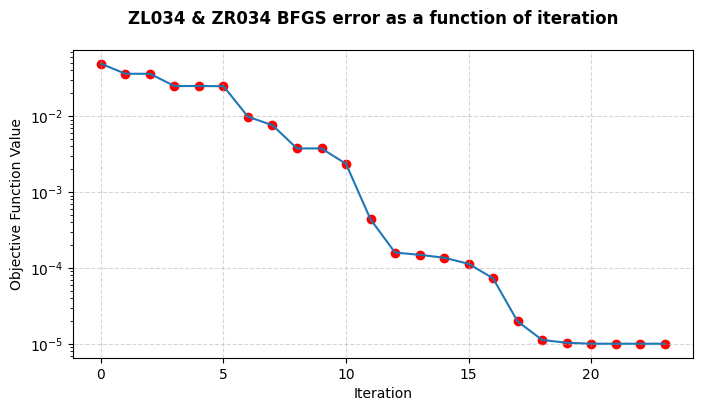

In [40]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

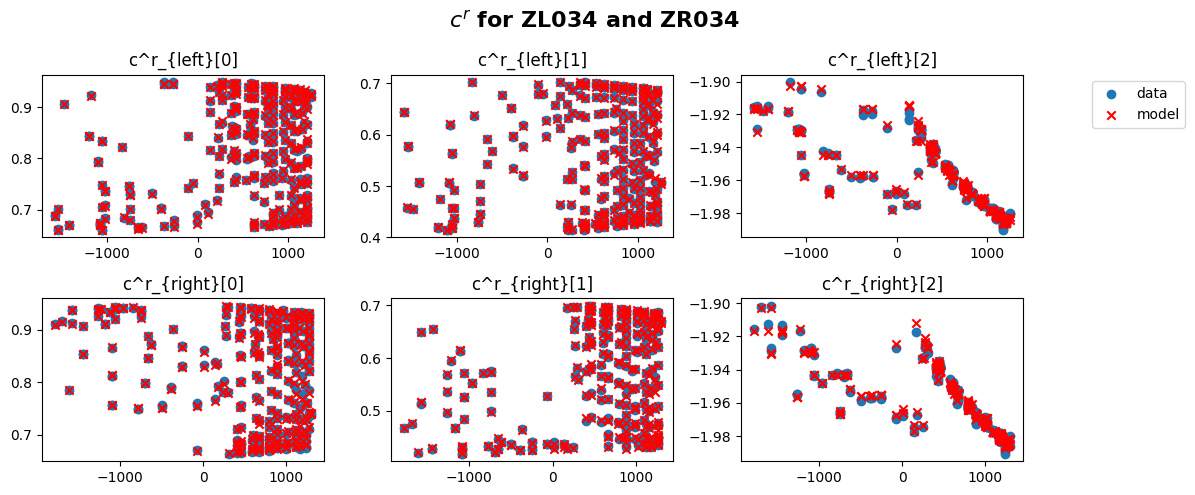

In [41]:
# plot model c_r vs data c_r
R_rrp = get_R_rrp()
c_r_data_left = []
c_r_model_left = []
for idx in range(zl34.shape[0]):
  f = zl34["fmc"][idx]
  R_rpm = get_R_rpm(idx, zl34)
  t_rpm = get_t_rpm(idx, zl34)
  c_r_data_left.append(get_c_r_data(idx, zl34))
  c_r_model_left.append(R_rrp @ R_rpm @ (t_mc_zl_0 + t_mc_zl_1*f) + R_rrp @ t_rpm + t_rrp)

c_r_data_right = []
c_r_model_right = []
for idx in range(zr34.shape[0]):
  f = zr34["fmc"][idx]
  R_rpm = get_R_rpm(idx, zr34)
  t_rpm = get_t_rpm(idx, zr34)
  c_r_data_right.append(get_c_r_data(idx, zr34))
  c_r_model_right.append(R_rrp @ R_rpm @ (t_mc_zr_0 + t_mc_zr_1*f) + R_rrp @ t_rpm + t_rrp)


# plot c_r data vs c_r model
fig, ax = plt.subplots(2, 3, figsize=(12,5))

for i in range(3):
  ax[0][i].scatter(zl34["fmc"], [c[i] for c in c_r_data_left], label="data")
  ax[0][i].scatter(zl34["fmc"], [c[i] for c in c_r_model_left], label="model", marker="x", color="red")
  ax[0][i].set_title("c^r_{left}"+f"[{i}]")
for i in range(3):
  ax[1][i].scatter(zr34["fmc"], [c[i] for c in c_r_data_right], label="data")
  ax[1][i].scatter(zr34["fmc"], [c[i] for c in c_r_model_right], label="model", marker="x", color="red")
  ax[1][i].set_title("c^r_{right}"+f"[{i}]")


ax[0][2].legend(["data", "model"], bbox_to_anchor=(1.6,1))
fig.suptitle("$c^r$ for ZL034 and ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

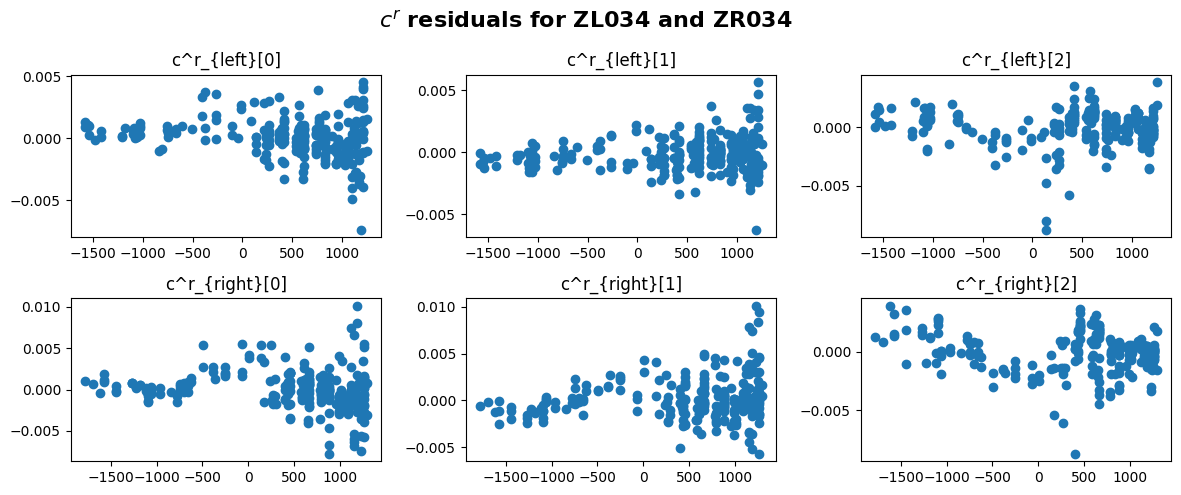

In [42]:
# plot model c_r vs data c_r
R_rrp = get_R_rrp()
c_r_residual_left = []
for idx in range(zl34.shape[0]):
  f = zl34["fmc"][idx]
  R_rpm = get_R_rpm(idx, zl34)
  t_rpm = get_t_rpm(idx, zl34)
  c_r_residual_left.append(get_c_r_data(idx, zl34) - (R_rrp @ R_rpm @ (t_mc_zl_0 + t_mc_zl_1*f) + R_rrp @ t_rpm + t_rrp))

c_r_residual_right = []
for idx in range(zr34.shape[0]):
  f = zr34["fmc"][idx]
  R_rpm = get_R_rpm(idx, zr34)
  t_rpm = get_t_rpm(idx, zr34)
  c_r_residual_right.append(get_c_r_data(idx, zr34) - (R_rrp @ R_rpm @ (t_mc_zr_0 + t_mc_zr_1*f) + R_rrp @ t_rpm + t_rrp))

# plot c_r data vs c_r model
fig, ax = plt.subplots(2, 3, figsize=(12,5))

for i in range(3):
  ax[0][i].scatter(zl34["fmc"], [c_res[i] for c_res in c_r_residual_left], label="data")
  ax[0][i].set_title("c^r_{left}"+f"[{i}]")
for i in range(3):
  ax[1][i].scatter(zr34["fmc"], [c_res[i] for c_res in c_r_residual_right], label="data")
  ax[1][i].set_title("c^r_{right}"+f"[{i}]")


fig.suptitle("$c^r$ residuals for ZL034 and ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()